In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('C:\\Users\\erisk\\Desktop\\PythonProjects\\fake-news-detector\\data\\raw\\news.csv')

print(df.head())
print(f"\nShape of dataset: {df.shape}")

   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  

Shape of dataset: (6335, 4)


In [4]:
from src.data_preprocessing import clean_text

df["text_clean"] = df["text"].apply(clean_text)
print(df[["text", "text_clean"]].head())

                                                text  \
0  Daniel Greenfield, a Shillman Journalism Fello...   
1  Google Pinterest Digg Linkedin Reddit Stumbleu...   
2  U.S. Secretary of State John F. Kerry said Mon...   
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...   
4  It's primary day in New York and front-runners...   

                                          text_clean  
0  daniel greenfield shillman journalism fellow f...  
1  google pinterest digg linkedin reddit stumbleu...  
2  u secretary state john f kerry said monday sto...  
3  kaydee king kaydeeking november lesson tonight...  
4  primary day new york front runners hillary cli...  


In [5]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label', 'text_clean'], dtype='str')

In [6]:
df["text"].isnull().sum()

np.int64(0)

In [7]:
from src.feature_extracion import extract_features

#texts = [
#    "fake news spreads fast",
#    "real news is verified",
#    "fake stories are dangerous"
#]

# x, vectorizer = extract_features(texts)
x, vectorizer = extract_features(df['text_clean'])
y = df['label']

print("Vocabulary: ", vectorizer.get_feature_names_out()[:10])
print("Shape: ", x.shape)

Vocabulary:  ['abandon' 'abandoned' 'abc' 'abc news' 'abdullah' 'abedin' 'ability'
 'able' 'abortion' 'abortions']
Shape:  (6335, 5000)


In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [15]:
import joblib

model = joblib.load("C:\\Users\\erisk\\Desktop\\PythonProjects\\fake-news-detector\\models\\fake_news_model.pkl")
vectorizer = joblib.load("C:\\Users\\erisk\\Desktop\\PythonProjects\\fake-news-detector\\models\\vectorizer.pkl")

sample_news = ["""
The government announced today a new set of economic reforms
aimed at reducing inflation and supporting small businesses.
The new policy will be introduced gradually over the next year.
"""]
sample_vector = vectorizer.transform(sample_news)
prediction = model.predict(sample_vector)

print("Prediction: ", prediction[0])

Prediction:  FAKE


In [10]:
print(df["label"].value_counts())
print(df.head())

label
REAL    3171
FAKE    3164
Name: count, dtype: int64
   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   

                                                text label  \
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE   
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE   
2  U.S. Secretary of State John F. Kerry said Mon...  REAL   
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE   
4  It's primary day in New York and front-runners...  REAL   

                                          text_clean  
0  daniel greenfield shillman journalism fellow f...  
1  google pinterest digg linkedin reddit stumbleu.

In [11]:
from sklearn.metrics import accuracy_score

y_predict = model.predict(x_test)
accuracy = accuracy_score(y_test, y_predict)
print("Accuracy: ", accuracy)

Accuracy:  0.9155485398579322


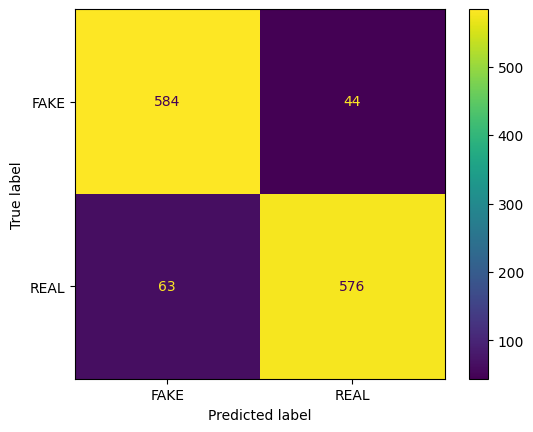

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from src.evaluate_model import evaluate

acc, cm, report = evaluate()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["FAKE", "REAL"])
disp.plot()
plt.show()